# MBO Foils AIC144 Single Large Foil Exploration

This notebook loads and explores a **single large MBO foil** detector data from the AIC144 experiment (2025-11-25).

**Note:** This foil is approximately twice as large as standard foils, so processing parameters (cutting, circle detection radii, probe radius) have been adjusted accordingly.

In [52]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd()
while not (project_root / 'pyproject.toml').exists() and project_root != project_root.parent:
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

In [53]:
from pathlib import Path
import pickle

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import scipy.ndimage as ndi

from src.data.analysis import Circle, read_tiff_img, create_circular_mask
from src.data.detector import DetectorData, DetectorImage

## Configuration

In [54]:
# Data path - single large foil from 2025-11-25
DATA_PATH = Path(r"C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\foils_mbo_aic144\2025-11-25")
BG_PATH = DATA_PATH / "tlo"

# Processing parameters - ADJUSTED FOR LARGE FOIL (2x standard size)
CUT_PX = 0  # No cutting - preserve full large foil image
GAUSSIAN_KERNEL = 3
MEDIAN_FILTER_SIZE = 5
N_SIGMA = 7
PROBE_RADIUS = 60  # Doubled from 30 for larger foil
STRIP_WIDTH = 30   # Increased for larger image
CLIP_PERCENTILE = 99.9

# Circle detection parameters - ADJUSTED FOR LARGE FOIL
CIRCLE_DETECTION_R = 200      # Inner mask radius for threshold calculation (doubled from 100)
CIRCLE_MIN_RADIUS = 200       # Min radius for Hough circle detection (doubled from 100)
CIRCLE_MAX_RADIUS = 400       # Max radius for Hough circle detection (doubled from 200)

# Edge refinement parameters
EDGE_SEARCH_DISTANCE_MM = 1.0  # Search for edge at this distance from initial circle
EDGE_MIN_VALUE = 150           # Minimum pixel value for edge detection
EDGE_MAX_VALUE = 200           # Maximum pixel value for edge detection

# Visualization parameters
PIXEL_SIZE_MM = 0.042         # Pixel size in mm (adjust based on your detector)
LOW_THRESHOLD_VALUE = 50      # Pixel value below which pixels are white

## Data Loading (Single Foil)

In [55]:
# Load single foil data directly (foil number 1)
foil_raw_path = next((DATA_PATH / "1").glob('**/*tif'))
foil_lv_path = next((DATA_PATH / "1_lv").glob('**/*tif'))

# Load background data
bg_raw_path = next(BG_PATH.glob('**/*tif'))
bg_lv_path = next(BG_PATH.with_name('tlo_lv').glob('**/*tif'))

# Read images
foil_raw_img = read_tiff_img(foil_raw_path, cut_px=CUT_PX)
foil_lv_img = read_tiff_img(foil_lv_path, cut_px=CUT_PX)
bg_raw_img = read_tiff_img(bg_raw_path, cut_px=CUT_PX)
bg_lv_img = read_tiff_img(bg_lv_path, cut_px=CUT_PX)

# Create detector data objects
foil_data = DetectorData(
    raw=DetectorImage(path=foil_raw_path, image=foil_raw_img),
    lv=DetectorImage(path=foil_lv_path, image=foil_lv_img),
    det_no=1
)

bg_data = DetectorData(
    raw=DetectorImage(path=bg_raw_path, image=bg_raw_img),
    lv=DetectorImage(path=bg_lv_path, image=bg_lv_img),
    det_no=-1
)

print("Data loaded:")
print(f"  Foil raw image shape: {foil_data.raw.image.shape}")
print(f"  Foil LV image shape: {foil_data.lv.image.shape}")
print(f"  Background raw shape: {bg_data.raw.image.shape}")
print(f"  Background LV shape: {bg_data.lv.image.shape}")
print(f"  Image size: {foil_data.raw.image.shape[0] * PIXEL_SIZE_MM:.1f} x {foil_data.raw.image.shape[1] * PIXEL_SIZE_MM:.1f} mm")

Data loaded:
  Foil raw image shape: (1024, 1024)
  Foil LV image shape: (1024, 1024)
  Background raw shape: (1024, 1024)
  Background LV shape: (1024, 1024)
  Image size: 43.0 x 43.0 mm


## Visualization Function

In [56]:
def compute_noise_stats(image: np.ndarray, strip_width: int) -> tuple[float, float]:
    """Compute noise statistics from image borders."""
    strips = np.concatenate([
        image[:, :strip_width].flatten(),
        image[:, -strip_width:].flatten(),
        image[:strip_width, :].flatten(),
        image[-strip_width:, :].flatten()
    ])
    return np.mean(strips), np.std(strips)


def create_white_green_red_cmap():
    """
    Create colormap: white at 0, green at 50%, red at 100%.
    Values below threshold should be set to NaN before plotting (will be white).
    """
    colors = [(1, 1, 1), (0, 1, 0), (1, 0, 0)]  # white, green, red
    positions = [0.0, 0.5, 1.0]
    cmap = LinearSegmentedColormap.from_list('white_green_red', list(zip(positions, colors)))
    cmap.set_bad(color='white')
    return cmap


def plot_foil_mm(image: np.ndarray, title: str, pixel_size_mm: float,
                 low_threshold_value: float = 50, 
                 center_x_px: float = None, center_y_px: float = None,
                 show_profiles: bool = True, ax=None, vmax: float = None):
    """
    Plot foil image with mm scale and proper colormap showing pixel values.
    
    Parameters:
    - image: 2D numpy array
    - title: plot title
    - pixel_size_mm: size of one pixel in mm
    - low_threshold_value: pixel value below which pixels are white
    - center_x_px, center_y_px: center position in pixels for profile lines
    - show_profiles: if True, draw profile lines
    - ax: matplotlib axis (creates new figure if None)
    - vmax: maximum value for colormap (auto if None)
    """
    standalone = False
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 8))
        standalone = True
    
    # Prepare image
    img_display = image.astype(np.float32).copy()
    
    # Set vmax
    if vmax is None:
        vmax = np.nanmax(img_display)
    
    # Mask values below threshold as NaN (will be white)
    img_display[img_display < low_threshold_value] = np.nan
    
    # Create extent in mm
    h, w = image.shape
    extent = [0, w * pixel_size_mm, h * pixel_size_mm, 0]  # [left, right, bottom, top]
    
    # Create colormap
    cmap = create_white_green_red_cmap()
    
    # Plot with pixel values (white at low_threshold, green at vmax/2, red at vmax)
    im = ax.imshow(img_display, cmap=cmap, vmin=0, vmax=vmax, extent=extent, aspect='equal')
    
    # Draw profile lines if center is provided
    if show_profiles and center_x_px is not None and center_y_px is not None:
        center_x_mm = center_x_px * pixel_size_mm
        center_y_mm = center_y_px * pixel_size_mm
        ax.axhline(center_y_mm, color='black', linewidth=1.5, linestyle='-', alpha=0.8)
        ax.axvline(center_x_mm, color='black', linewidth=1.5, linestyle='-', alpha=0.8)
    
    ax.set_xlabel('x [mm]')
    ax.set_ylabel('y [mm]')
    ax.set_title(title)
    
    # Add colorbar with pixel values
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Pixel Value')
    
    if standalone:
        plt.tight_layout()
        plt.show()
    
    return im


def plot_profiles_mm(image: np.ndarray, center_x_px: int, center_y_px: int,
                     pixel_size_mm: float, profile_width_px: int = 20, title: str = ""):
    """
    Plot horizontal and vertical profiles through the center in mm scale.
    """
    h, w = image.shape
    
    # Extract profiles
    y_start = max(0, center_y_px - profile_width_px // 2)
    y_end = min(h, center_y_px + profile_width_px // 2)
    x_start = max(0, center_x_px - profile_width_px // 2)
    x_end = min(w, center_x_px + profile_width_px // 2)
    
    h_profile = image[y_start:y_end, :].mean(axis=0)
    v_profile = image[:, x_start:x_end].mean(axis=1)
    
    # Create mm scale
    x_mm = np.arange(w) * pixel_size_mm
    y_mm = np.arange(h) * pixel_size_mm
    center_x_mm = center_x_px * pixel_size_mm
    center_y_mm = center_y_px * pixel_size_mm
    
    _, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Horizontal profile
    axes[0].plot(x_mm, h_profile, 'b-', linewidth=1)
    axes[0].axvline(center_x_mm, color='r', linestyle='--', alpha=0.7, label=f'Center x={center_x_mm:.1f} mm')
    axes[0].set(xlabel='x [mm]', ylabel='Pixel Value', 
                title=f'Horizontal Profile (y = {center_y_mm:.1f} mm)')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)
    
    # Vertical profile
    axes[1].plot(y_mm, v_profile, 'b-', linewidth=1)
    axes[1].axvline(center_y_mm, color='r', linestyle='--', alpha=0.7, label=f'Center y={center_y_mm:.1f} mm')
    axes[1].set(xlabel='y [mm]', ylabel='Pixel Value', 
                title=f'Vertical Profile (x = {center_x_mm:.1f} mm)')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)
    
    if title:
        plt.gcf().suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_detector_data(lv_image: np.ndarray, raw_image: np.ndarray, title: str,
                       gaussian_sigma: int = 3, n_sigma: int = 7, 
                       probe_radius: float = 30, strip_width: int = 20,
                       clip_percentile: float = 99.9):
    """Plot live view and raw detector images with histograms (legacy function)."""
    cmap = LinearSegmentedColormap.from_list('green_red', [(0, 1, 0), (1, 0, 0)])
    cmap.set_bad(color='white')
    
    # Compute noise thresholds
    lv_mean, lv_std = compute_noise_stats(lv_image, strip_width)
    raw_mean, raw_std = compute_noise_stats(raw_image, strip_width)
    
    # Apply smoothing and mask
    lv_smooth = ndi.gaussian_filter(lv_image, sigma=gaussian_sigma).astype(np.float32)
    raw_smooth = ndi.gaussian_filter(raw_image, sigma=gaussian_sigma).astype(np.float32)
    
    detector_mask = lv_smooth > lv_mean + n_sigma * lv_std
    lv_smooth[~detector_mask] = 0
    raw_smooth[~detector_mask] = 0
    
    # Find center of mass and create probe mask
    lv_cm = ndi.center_of_mass(lv_smooth)
    lv_probe_mask = create_circular_mask(lv_smooth, Circle(x=lv_cm[1], y=lv_cm[0], r=probe_radius))
    raw_cm = ndi.center_of_mass(raw_smooth)
    raw_probe_mask = create_circular_mask(raw_smooth, Circle(x=raw_cm[1], y=raw_cm[0], r=probe_radius))
    
    # Compute display limits from probe region
    lv_probe_mean = np.nanmean(lv_smooth[lv_probe_mask])
    lv_probe_std = np.nanstd(lv_smooth[lv_probe_mask])
    raw_probe_mean = np.nanmean(raw_smooth[raw_probe_mask])
    raw_probe_std = np.nanstd(raw_smooth[raw_probe_mask])
    
    lv_vmin, lv_vmax = lv_probe_mean - n_sigma * lv_probe_std, lv_probe_mean + n_sigma * lv_probe_std
    raw_vmin, raw_vmax = raw_probe_mean - n_sigma * raw_probe_std, raw_probe_mean + n_sigma * raw_probe_std
    
    # Mask outliers
    lv_smooth[(lv_smooth < lv_vmin) | (lv_smooth > lv_vmax)] = np.nan
    raw_smooth[(raw_smooth < raw_vmin) | (raw_smooth > raw_vmax)] = np.nan
    
    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    lv_upper = np.percentile(lv_image, clip_percentile)
    raw_upper = np.percentile(raw_image, clip_percentile)
    
    # LV histogram
    axes[0, 0].hist(lv_image.flatten(), bins=100, range=(0, lv_upper), density=True, histtype='step', label='All data')
    axes[0, 0].hist(lv_smooth[lv_probe_mask].flatten(), bins=100, range=(0, lv_upper), density=True, histtype='step', color='blue', label='Probe region')
    axes[0, 0].axvline(lv_mean, color='r', linestyle='--', label='Noise mean')
    axes[0, 0].axvline(lv_mean + n_sigma * lv_std, color='g', linestyle='--', label=f'+{n_sigma}σ')
    axes[0, 0].set(yscale='log', xlim=(0, None), title='LV Histogram')
    axes[0, 0].legend(fontsize=8)
    axes[0, 0].grid(True, alpha=0.3)
    
    # Raw histogram
    axes[1, 0].hist(raw_image.flatten(), bins=100, range=(0, raw_upper), density=True, histtype='step', label='All data')
    axes[1, 0].hist(raw_smooth[raw_probe_mask].flatten(), bins=100, range=(0, raw_upper), density=True, histtype='step', color='blue', label='Probe region')
    axes[1, 0].axvline(raw_mean, color='r', linestyle='--', label='Noise mean')
    axes[1, 0].axvline(raw_mean + n_sigma * raw_std, color='g', linestyle='--', label=f'+{n_sigma}σ')
    axes[1, 0].set(yscale='log', xlim=(0, None), title='Raw Histogram')
    axes[1, 0].legend(fontsize=8)
    axes[1, 0].grid(True, alpha=0.3)
    
    # LV image
    im0 = axes[0, 1].imshow(lv_smooth, cmap=cmap, vmin=lv_vmin, vmax=lv_vmax)
    axes[0, 1].scatter(*lv_cm[::-1], color='blue', s=20)
    axes[0, 1].add_patch(plt.Circle(lv_cm[::-1], probe_radius, color='blue', fill=False, linewidth=1.5))
    axes[0, 1].set_title('LV Image')
    axes[0, 1].grid(True, alpha=0.3)
    plt.colorbar(im0, ax=axes[0, 1], shrink=0.8)
    
    # Raw image
    im1 = axes[1, 1].imshow(raw_smooth, cmap=cmap, vmin=raw_vmin, vmax=raw_vmax)
    axes[1, 1].scatter(*raw_cm[::-1], color='blue', s=20)
    axes[1, 1].add_patch(plt.Circle(raw_cm[::-1], probe_radius, color='blue', fill=False, linewidth=1.5))
    axes[1, 1].set_title('Raw Image')
    axes[1, 1].grid(True, alpha=0.3)
    plt.colorbar(im1, ax=axes[1, 1], shrink=0.8)
    
    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    plt.show()
    plt.close(fig)

## Raw Data Visualization (Single Foil)

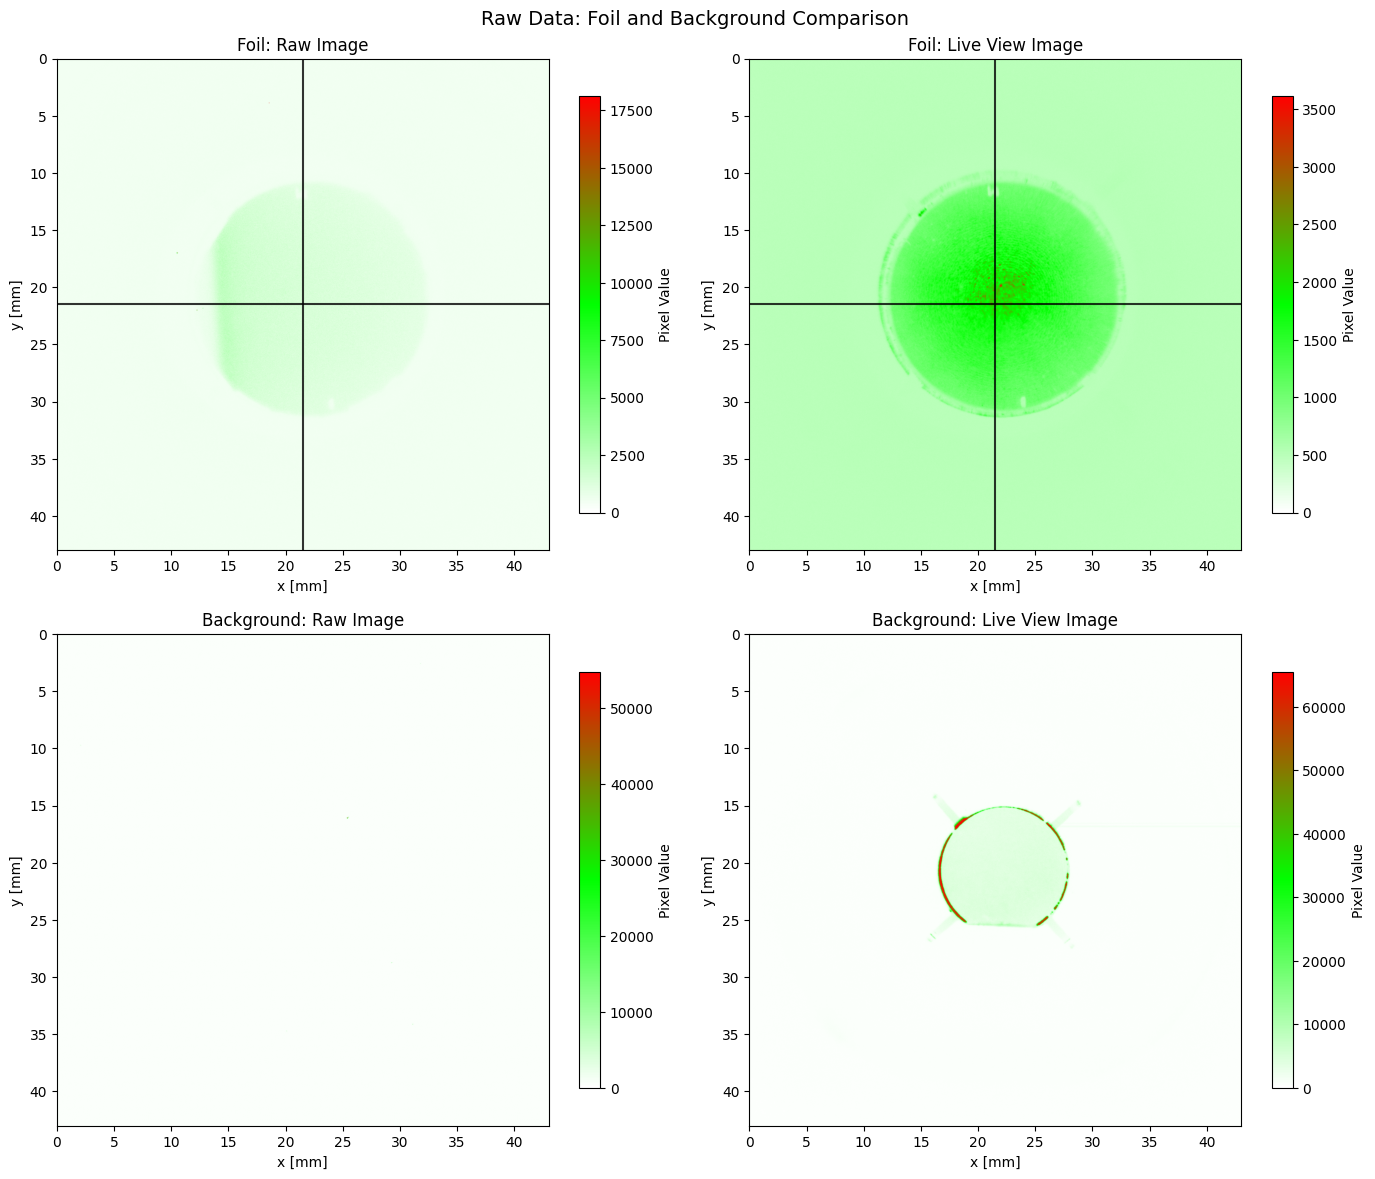

In [57]:
# Visualize raw data for foil and background
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Get center for profile lines (use image center initially)
init_center_x = foil_data.raw.image.shape[1] // 2
init_center_y = foil_data.raw.image.shape[0] // 2

# Foil raw image
plot_foil_mm(foil_data.raw.image, "Foil: Raw Image", PIXEL_SIZE_MM, 
             LOW_THRESHOLD_VALUE, init_center_x, init_center_y, 
             show_profiles=True, ax=axes[0, 0])

# Foil LV image
plot_foil_mm(foil_data.lv.image, "Foil: Live View Image", PIXEL_SIZE_MM,
             LOW_THRESHOLD_VALUE, init_center_x, init_center_y,
             show_profiles=True, ax=axes[0, 1])

# Background raw image
plot_foil_mm(bg_data.raw.image, "Background: Raw Image", PIXEL_SIZE_MM,
             LOW_THRESHOLD_VALUE, init_center_x, init_center_y,
             show_profiles=False, ax=axes[1, 0])

# Background LV image
plot_foil_mm(bg_data.lv.image, "Background: Live View Image", PIXEL_SIZE_MM,
             LOW_THRESHOLD_VALUE, init_center_x, init_center_y,
             show_profiles=False, ax=axes[1, 1])

fig.suptitle('Raw Data: Foil and Background Comparison', fontsize=14)
plt.tight_layout()
plt.show()

## Background Subtraction and Denoising (Single Foil)

In [58]:
def subtract_background_safe(image: np.ndarray, bg_image: np.ndarray) -> np.ndarray:
    """Subtract background safely for uint16 images by shifting to avoid negative values."""
    result = image.copy()
    offset = bg_image.max()
    np.add(result, offset, out=result)
    np.subtract(result, bg_image, out=result)
    np.clip(result, a_min=offset, a_max=None, out=result)
    np.subtract(result, offset, out=result)
    return result


# Apply background subtraction and median denoising to single foil
bg_sub_raw = subtract_background_safe(foil_data.raw.image, bg_data.raw.image)
denoised_raw = ndi.median_filter(bg_sub_raw, size=MEDIAN_FILTER_SIZE)

processed_foil = DetectorData(
    raw=DetectorImage(path=foil_data.raw.path, image=denoised_raw),
    lv=foil_data.lv,
    det_no=1
)

print("Foil processed:")
print(f"  Original raw range: [{foil_data.raw.image.min():.1f}, {foil_data.raw.image.max():.1f}]")
print(f"  After background subtraction: [{bg_sub_raw.min():.1f}, {bg_sub_raw.max():.1f}]")
print(f"  After median filter: [{processed_foil.raw.image.min():.1f}, {processed_foil.raw.image.max():.1f}]")

Foil processed:
  Original raw range: [437.0, 18106.0]
  After background subtraction: [0.0, 6507.0]
  After median filter: [0.0, 1973.0]


## Processed Foil Visualization (After Background Subtraction)

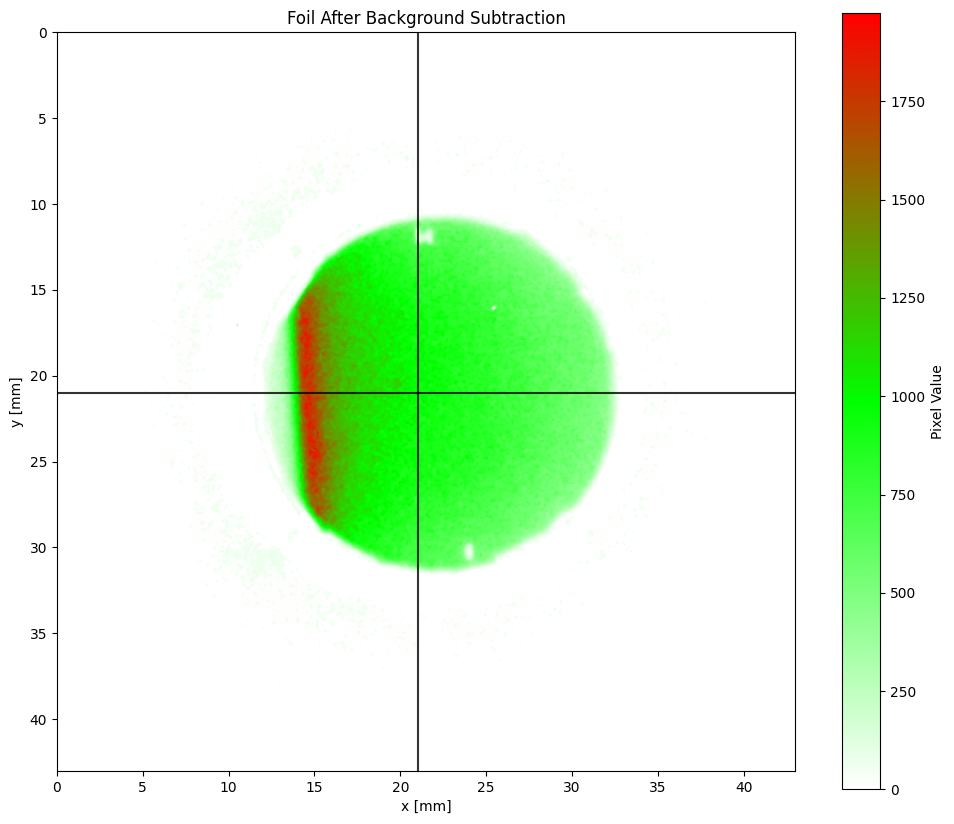

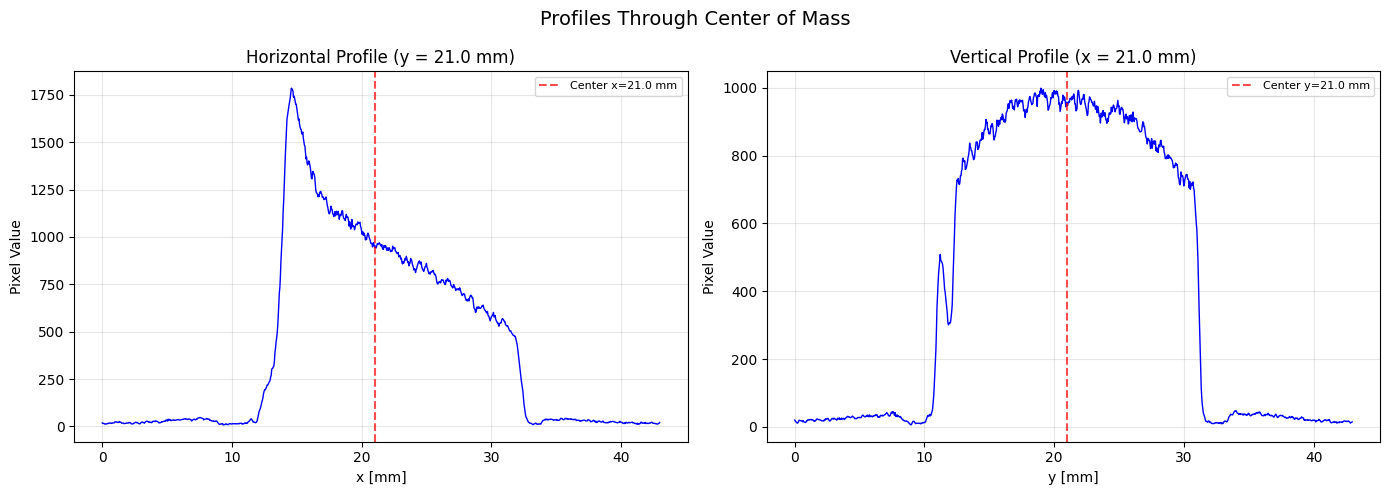

In [59]:
# Visualize foil after background subtraction with mm scale
# Use center of mass for profile lines
processed_smooth = ndi.gaussian_filter(processed_foil.raw.image, sigma=GAUSSIAN_KERNEL)
cm = ndi.center_of_mass(processed_smooth)
center_x_px = int(cm[1])
center_y_px = int(cm[0])

# Main plot with profile lines
_, ax = plt.subplots(figsize=(10, 10))
plot_foil_mm(processed_foil.raw.image, 
             "Foil After Background Subtraction", 
             PIXEL_SIZE_MM, LOW_THRESHOLD_VALUE,
             center_x_px, center_y_px, show_profiles=True, ax=ax)
plt.tight_layout()
plt.show()

# Profiles in mm
plot_profiles_mm(processed_foil.raw.image, center_x_px, center_y_px, 
                 PIXEL_SIZE_MM, profile_width_px=20,
                 title="Profiles Through Center of Mass")

## Detector Circle Detection (Adjusted for Large Foil)

In [60]:
# Custom circle detection with parameters adjusted for large foil
def img_for_circle_detection_large(data: np.ndarray, r: float = 200, nsigma: float = 2.) -> np.ndarray:
    """Prepare image for circle detection with adjustable inner mask radius."""
    output = np.zeros(shape=data.shape, dtype='uint8')
    
    circle_inside_det = Circle(x=data.shape[0] / 2, y=data.shape[1] / 2, r=r)
    mask_inside_det = create_circular_mask(data, circle_inside_det)
    
    upper_threshold = np.mean(data, where=mask_inside_det) + nsigma * np.std(data, where=mask_inside_det)
    lower_threshold = np.mean(data, where=mask_inside_det) - nsigma * np.std(data, where=mask_inside_det)
    
    output[(data > lower_threshold) & (data < upper_threshold)] = 255
    output[np.isnan(data)] = 255
    return output


def find_circle_hough_large(data: np.ndarray, min_radius: int = 200, max_radius: int = 400) -> Circle:
    """Find circle using Hough transform with parameters for large foil."""
    import cv2
    hough_results = cv2.HoughCircles(
        data,
        cv2.HOUGH_GRADIENT,
        dp=1,
        minDist=10000,
        param1=10,
        param2=0.9,
        minRadius=min_radius,
        maxRadius=max_radius
    )
    
    if hough_results is None:
        print("No detector found by Hough method")
        return Circle()
    elif hough_results.shape[0] > 1:
        print("More than one shape found by Hough method")
        return Circle()
    else:
        return Circle(
            x=float(hough_results[0, 0, 0]),
            y=float(hough_results[0, 0, 1]),
            r=float(hough_results[0, 0, 2])
        )


def refine_circle_by_edge(image: np.ndarray, initial_circle: Circle, 
                          search_distance_mm: float, pixel_size_mm: float,
                          edge_min_value: float, edge_max_value: float,
                          n_angles: int = 360) -> Circle:
    """
    Refine circle by finding edge pixels within a band around the initial circle.
    
    Parameters:
    - image: 2D numpy array (background-subtracted)
    - initial_circle: Initial circle estimate
    - search_distance_mm: Search for edge at this distance from circle (in mm)
    - pixel_size_mm: Pixel size in mm
    - edge_min_value: Minimum pixel value for edge
    - edge_max_value: Maximum pixel value for edge
    - n_angles: Number of radial directions to sample
    
    Returns:
    - Refined Circle with updated center and radius
    """
    search_distance_px = search_distance_mm / pixel_size_mm
    
    # Sample angles
    angles = np.linspace(0, 2 * np.pi, n_angles, endpoint=False)
    
    # Find edge points along each radial direction
    edge_points = []
    for angle in angles:
        # Search along радиальное направление around initial radius
        for dr in np.linspace(-search_distance_px, search_distance_px, 50):
            r = initial_circle.r + dr
            x = initial_circle.x + r * np.cos(angle)
            y = initial_circle.y + r * np.sin(angle)
            
            # Check bounds
            xi, yi = int(round(x)), int(round(y))
            if 0 <= xi < image.shape[1] and 0 <= yi < image.shape[0]:
                pixel_value = image[yi, xi]
                if edge_min_value <= pixel_value <= edge_max_value:
                    edge_points.append((x, y))
                    break  # Found edge in this direction
    
    if len(edge_points) < 10:
        print(f"Warning: Only {len(edge_points)} edge points found, keeping initial circle")
        return initial_circle
    
    edge_points = np.array(edge_points)
    
    # Fit circle to edge points using least squares
    # (x - cx)^2 + (y - cy)^2 = r^2
    # Linearized: 2*cx*x + 2*cy*y + (r^2 - cx^2 - cy^2) = x^2 + y^2
    # Let a = 2*cx, b = 2*cy, c = r^2 - cx^2 - cy^2
    # Then: a*x + b*y + c = x^2 + y^2
    
    x = edge_points[:, 0]
    y = edge_points[:, 1]
    
    A = np.column_stack([x, y, np.ones_like(x)])
    b = x**2 + y**2
    
    try:
        result, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
        cx = result[0] / 2
        cy = result[1] / 2
        r = np.sqrt(result[2] + cx**2 + cy**2)
        
        refined_circle = Circle(x=float(cx), y=float(cy), r=float(r))
        print(f"Edge refinement: found {len(edge_points)} edge points")
        return refined_circle
    except np.linalg.LinAlgError:
        print("Warning: Circle fitting failed, keeping initial circle")
        return initial_circle


# Step 1: Initial circle detection on background-subtracted image
print("=== Initial Circle Detection (on background-subtracted image) ===")
raw_for_detection = img_for_circle_detection_large(
    processed_foil.raw.image, 
    r=CIRCLE_DETECTION_R
)
initial_circle = find_circle_hough_large(
    raw_for_detection, 
    min_radius=CIRCLE_MIN_RADIUS, 
    max_radius=CIRCLE_MAX_RADIUS
)

print(f"Initial circle:")
print(f"  Center: ({initial_circle.x:.1f}, {initial_circle.y:.1f}) px = ({initial_circle.x * PIXEL_SIZE_MM:.2f}, {initial_circle.y * PIXEL_SIZE_MM:.2f}) mm")
print(f"  Radius: {initial_circle.r:.1f} px = {initial_circle.r * PIXEL_SIZE_MM:.2f} mm")

# Step 2: Refine circle by edge detection
print(f"\n=== Edge Refinement (pixels {EDGE_MIN_VALUE}-{EDGE_MAX_VALUE}, {EDGE_SEARCH_DISTANCE_MM} mm from circle) ===")
refined_circle = refine_circle_by_edge(
    processed_foil.raw.image,
    initial_circle,
    search_distance_mm=EDGE_SEARCH_DISTANCE_MM,
    pixel_size_mm=PIXEL_SIZE_MM,
    edge_min_value=EDGE_MIN_VALUE,
    edge_max_value=EDGE_MAX_VALUE
)

print(f"Refined circle:")
print(f"  Center: ({refined_circle.x:.1f}, {refined_circle.y:.1f}) px = ({refined_circle.x * PIXEL_SIZE_MM:.2f}, {refined_circle.y * PIXEL_SIZE_MM:.2f}) mm")
print(f"  Radius: {refined_circle.r:.1f} px = {refined_circle.r * PIXEL_SIZE_MM:.2f} mm")

# Use refined circle for final result
circle = refined_circle

final_foil = DetectorData(
    raw=processed_foil.raw,
    lv=processed_foil.lv,
    det_no=1,
    circle=circle
)

print(f"\n=== Final Circle ===")
print(f"  Center: ({circle.x:.1f}, {circle.y:.1f}) px = ({circle.x * PIXEL_SIZE_MM:.2f}, {circle.y * PIXEL_SIZE_MM:.2f}) mm")
print(f"  Radius: {circle.r:.1f} px = {circle.r * PIXEL_SIZE_MM:.2f} mm")

=== Initial Circle Detection (on background-subtracted image) ===
Initial circle:
  Center: (525.5, 496.5) px = (22.07, 20.85) mm
  Radius: 237.2 px = 9.96 mm

=== Edge Refinement (pixels 150-200, 1.0 mm from circle) ===
Edge refinement: found 294 edge points
Refined circle:
  Center: (532.5, 500.7) px = (22.36, 21.03) mm
  Radius: 241.3 px = 10.14 mm

=== Final Circle ===
  Center: (532.5, 500.7) px = (22.36, 21.03) mm
  Radius: 241.3 px = 10.14 mm


## Processed Data Visualization (Single Foil with Circle)

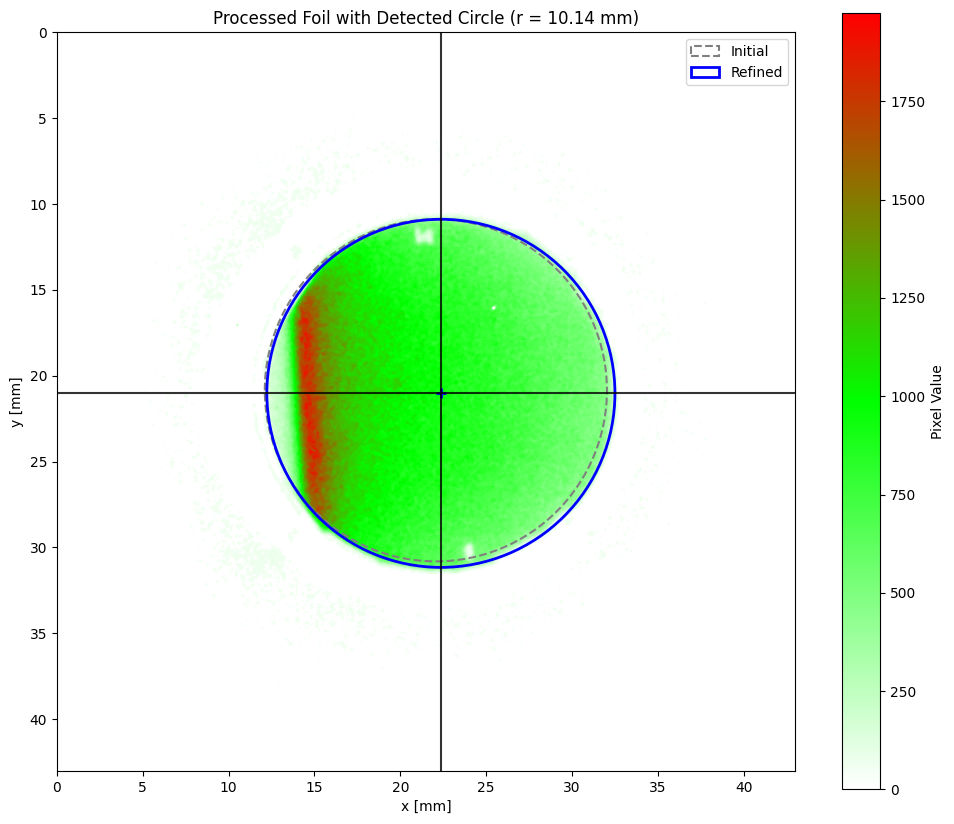

In [61]:
# Visualize processed data with detected circles (initial and refined) - mm scale, pixel values
_, ax = plt.subplots(figsize=(10, 10))
h, w = final_foil.raw.image.shape
extent = [0, w * PIXEL_SIZE_MM, h * PIXEL_SIZE_MM, 0]

# Display with custom colormap - pixel values
img_display = final_foil.raw.image.astype(np.float32).copy()
img_max = np.nanmax(img_display)
img_display[img_display < LOW_THRESHOLD_VALUE] = np.nan

cmap = create_white_green_red_cmap()
im = ax.imshow(img_display, cmap=cmap, vmin=0, vmax=img_max, extent=extent, aspect='equal')

# Draw initial circle (dashed, gray)
if initial_circle.r > 0:
    init_x_mm = initial_circle.x * PIXEL_SIZE_MM
    init_y_mm = initial_circle.y * PIXEL_SIZE_MM
    init_r_mm = initial_circle.r * PIXEL_SIZE_MM
    init_patch = plt.Circle((init_x_mm, init_y_mm), init_r_mm, 
                             color='gray', fill=False, linewidth=1.5, linestyle='--', label='Initial')
    ax.add_patch(init_patch)

# Draw refined circle (solid, blue)
if final_foil.circle.r > 0:
    circle_x_mm = final_foil.circle.x * PIXEL_SIZE_MM
    circle_y_mm = final_foil.circle.y * PIXEL_SIZE_MM
    circle_r_mm = final_foil.circle.r * PIXEL_SIZE_MM
    circle_patch = plt.Circle((circle_x_mm, circle_y_mm), circle_r_mm, 
                               color='blue', fill=False, linewidth=2, label='Refined')
    ax.add_patch(circle_patch)
    ax.scatter(circle_x_mm, circle_y_mm, color='blue', s=50, marker='+', linewidths=2)
    
    # Draw profile lines
    ax.axhline(circle_y_mm, color='black', linewidth=1.5, linestyle='-', alpha=0.8)
    ax.axvline(circle_x_mm, color='black', linewidth=1.5, linestyle='-', alpha=0.8)

ax.set_xlabel('x [mm]')
ax.set_ylabel('y [mm]')
ax.set_title(f'Processed Foil with Detected Circle (r = {final_foil.circle.r * PIXEL_SIZE_MM:.2f} mm)')
ax.legend(loc='upper right')

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Pixel Value')

plt.tight_layout()
plt.show()

## Profile Analysis (Single Large Foil)

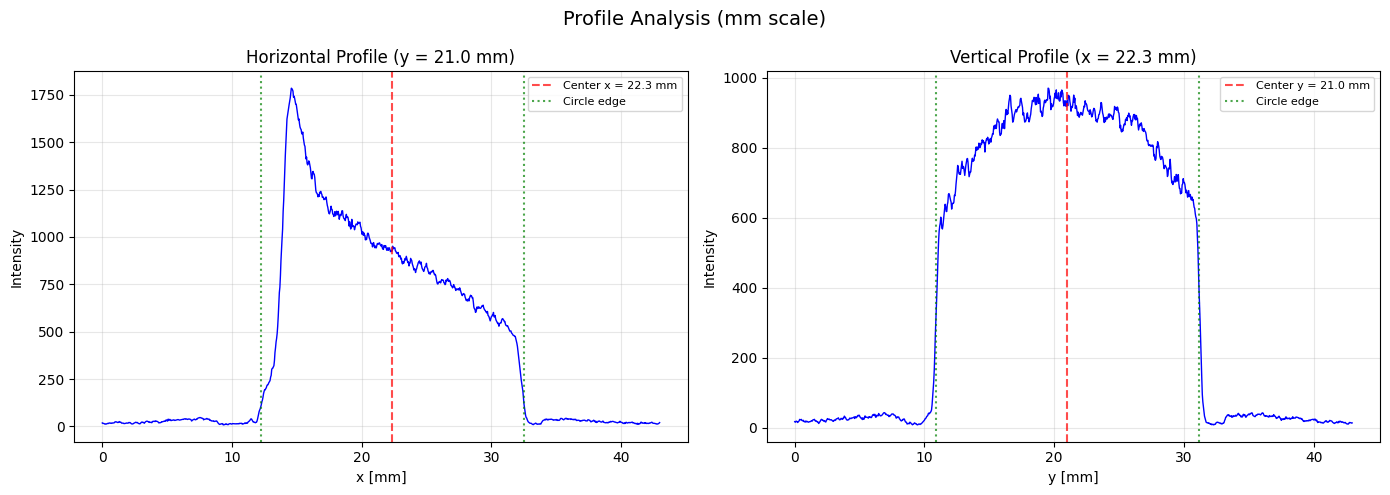

In [62]:
# Extract horizontal and vertical profiles through the detected circle center
center_y_px = int(final_foil.circle.y)
center_x_px = int(final_foil.circle.x)
profile_width_px = 20  # Average over this many rows/columns

h, w = final_foil.raw.image.shape

# Extract profiles
y_start = max(0, center_y_px - profile_width_px // 2)
y_end = min(h, center_y_px + profile_width_px // 2)
x_start = max(0, center_x_px - profile_width_px // 2)
x_end = min(w, center_x_px + profile_width_px // 2)

h_profile = final_foil.raw.image[y_start:y_end, :].mean(axis=0)
v_profile = final_foil.raw.image[:, x_start:x_end].mean(axis=1)

# Create mm scale
x_mm = np.arange(w) * PIXEL_SIZE_MM
y_mm = np.arange(h) * PIXEL_SIZE_MM
center_x_mm = center_x_px * PIXEL_SIZE_MM
center_y_mm = center_y_px * PIXEL_SIZE_MM
circle_r_mm = final_foil.circle.r * PIXEL_SIZE_MM

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Horizontal profile
axes[0].plot(x_mm, h_profile, 'b-', linewidth=1)
axes[0].axvline(center_x_mm, color='r', linestyle='--', alpha=0.7, label=f'Center x = {center_x_mm:.1f} mm')
if final_foil.circle.r > 0:
    axes[0].axvline(center_x_mm - circle_r_mm, color='g', linestyle=':', alpha=0.7, label='Circle edge')
    axes[0].axvline(center_x_mm + circle_r_mm, color='g', linestyle=':', alpha=0.7)
axes[0].set(xlabel='x [mm]', ylabel='Intensity', 
            title=f'Horizontal Profile (y = {center_y_mm:.1f} mm)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Vertical profile
axes[1].plot(y_mm, v_profile, 'b-', linewidth=1)
axes[1].axvline(center_y_mm, color='r', linestyle='--', alpha=0.7, label=f'Center y = {center_y_mm:.1f} mm')
if final_foil.circle.r > 0:
    axes[1].axvline(center_y_mm - circle_r_mm, color='g', linestyle=':', alpha=0.7, label='Circle edge')
    axes[1].axvline(center_y_mm + circle_r_mm, color='g', linestyle=':', alpha=0.7)
axes[1].set(xlabel='y [mm]', ylabel='Intensity', 
            title=f'Vertical Profile (x = {center_x_mm:.1f} mm)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

fig.suptitle('Profile Analysis (mm scale)', fontsize=14)
plt.tight_layout()
plt.show()

## Circle Detection Verification

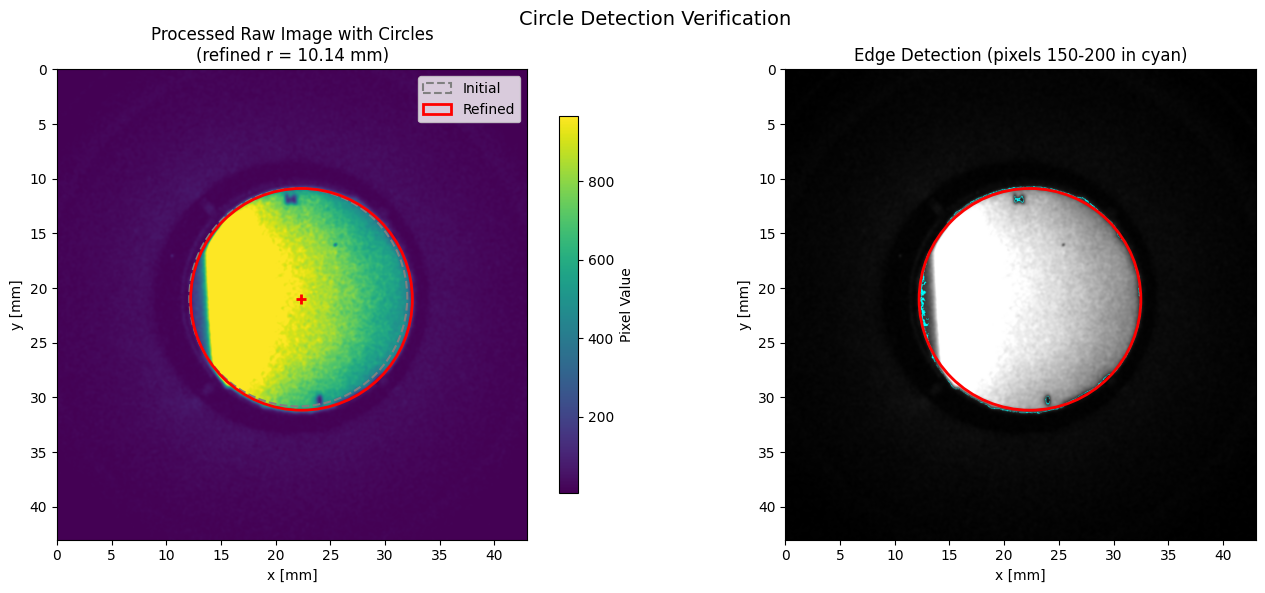

In [63]:
# Visualize detected circles (initial and refined) overlaid on the Raw image with mm scale
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

h, w = final_foil.raw.image.shape
extent = [0, w * PIXEL_SIZE_MM, h * PIXEL_SIZE_MM, 0]

# Left: Raw image with both circles
raw_display = ndi.gaussian_filter(final_foil.raw.image.copy(), sigma=2).astype(np.float32)
vmin_raw, vmax_raw = np.percentile(raw_display[raw_display > 0], [5, 95])

im0 = axes[0].imshow(raw_display, cmap='viridis', vmin=vmin_raw, vmax=vmax_raw, extent=extent)
if initial_circle.r > 0:
    init_x_mm = initial_circle.x * PIXEL_SIZE_MM
    init_y_mm = initial_circle.y * PIXEL_SIZE_MM
    init_r_mm = initial_circle.r * PIXEL_SIZE_MM
    init_patch = plt.Circle((init_x_mm, init_y_mm), init_r_mm,
                             color='gray', fill=False, linewidth=1.5, linestyle='--', label='Initial')
    axes[0].add_patch(init_patch)
if final_foil.circle.r > 0:
    circle_x_mm = final_foil.circle.x * PIXEL_SIZE_MM
    circle_y_mm = final_foil.circle.y * PIXEL_SIZE_MM
    circle_r_mm = final_foil.circle.r * PIXEL_SIZE_MM
    circle_patch = plt.Circle((circle_x_mm, circle_y_mm), circle_r_mm,
                               color='red', fill=False, linewidth=2, linestyle='-', label='Refined')
    axes[0].add_patch(circle_patch)
    axes[0].scatter(circle_x_mm, circle_y_mm, color='red', s=50, marker='+', linewidths=2)
axes[0].set_xlabel('x [mm]')
axes[0].set_ylabel('y [mm]')
axes[0].set_title(f'Processed Raw Image with Circles\n(refined r = {final_foil.circle.r * PIXEL_SIZE_MM:.2f} mm)')
axes[0].legend(loc='upper right')
cbar0 = plt.colorbar(im0, ax=axes[0], shrink=0.8)
cbar0.set_label('Pixel Value')

# Right: Edge detection visualization
# Show pixels in edge range as a different color
edge_mask = (final_foil.raw.image >= EDGE_MIN_VALUE) & (final_foil.raw.image <= EDGE_MAX_VALUE)
edge_display = np.zeros((h, w, 3), dtype=np.float32)
edge_display[..., 0] = raw_display / vmax_raw  # Red channel = raw image
edge_display[..., 1] = raw_display / vmax_raw  # Green channel
edge_display[..., 2] = raw_display / vmax_raw  # Blue channel
edge_display = np.clip(edge_display, 0, 1)
# Highlight edge pixels in cyan
edge_display[edge_mask, 0] = 0
edge_display[edge_mask, 1] = 1
edge_display[edge_mask, 2] = 1

axes[1].imshow(edge_display, extent=extent)
if final_foil.circle.r > 0:
    circle_patch = plt.Circle((circle_x_mm, circle_y_mm), circle_r_mm,
                               color='red', fill=False, linewidth=2, linestyle='-')
    axes[1].add_patch(circle_patch)
axes[1].set_xlabel('x [mm]')
axes[1].set_ylabel('y [mm]')
axes[1].set_title(f'Edge Detection (pixels {EDGE_MIN_VALUE}-{EDGE_MAX_VALUE} in cyan)')

fig.suptitle('Circle Detection Verification', fontsize=14)
plt.tight_layout()
plt.show()

## Save Processed Data (Single Foil)

In [64]:
# Save processed single foil data
output_path = DATA_PATH / 'mbo_aic144_single_foil_processed.pkl'

with open(output_path, 'wb') as f:
    pickle.dump(final_foil, f)

print(f"Single foil data saved to: {output_path}")
print(f"  Shape: {final_foil.raw.image.shape}")
print(f"  Size: {final_foil.raw.image.shape[0] * PIXEL_SIZE_MM:.1f} x {final_foil.raw.image.shape[1] * PIXEL_SIZE_MM:.1f} mm")
print(f"  Circle: center=({final_foil.circle.x * PIXEL_SIZE_MM:.2f}, {final_foil.circle.y * PIXEL_SIZE_MM:.2f}) mm, r={final_foil.circle.r * PIXEL_SIZE_MM:.2f} mm")

Single foil data saved to: C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\foils_mbo_aic144\2025-11-25\mbo_aic144_single_foil_processed.pkl
  Shape: (1024, 1024)
  Size: 43.0 x 43.0 mm
  Circle: center=(22.36, 21.03) mm, r=10.14 mm
